In [2]:
import pandas as pd
import math
import matplotlib.pyplot as plt

dfa = pd.read_parquet(r'C:\Users\irees\Downloads\Summer_learning\research26\Brazil_22_lvl0\scintpi3_20221004_2000_359060.7812W_72122.4141S_v325_lvl0.pq')
dfb = pd.read_parquet(r'C:\Users\irees\Downloads\Summer_learning\research26\Brazil_22_lvl0\scintpi3_20221004_2000_359072.7500W_72126.9375S_v325_lvl0.pq')
display(dfa.head())
dfb.head()

,leap,cons,svid,elev,azim,snr1,snr2,snr3,pst3,rst3,cph1,cph2,cph3,rng1,rng2,rng3,lon,lat,hei,datetime
0,18,0,31,6,279,41,35,0,0,0,1.291349e+08,1.006247e+08,0.0,2.457355e+07,2.457357e+07,0.0,-359060.78125,-72122.414062,560.80603,2022-10-04 20:00:18.250
1,18,0,12,29,23,43,40,0,0,0,1.178793e+08,9.185398e+07,0.0,2.243167e+07,2.243168e+07,0.0,-359060.78125,-72122.414062,560.80603,2022-10-04 20:00:18.250
2,18,0,2,16,141,40,0,0,0,0,1.233021e+08,0.000000e+00,0.0,2.346360e+07,0.000000e+00,0.0,-359060.78125,-72122.414062,560.80603,2022-10-04 20:00:18.250
3,18,0,15,36,92,44,42,0,0,0,1.169097e+08,9.109848e+07,0.0,2.224718e+07,2.224719e+07,0.0,-359060.78125,-72122.414062,560.80603,2022-10-04 20:00:18.250
4,18,0,23,66,297,46,47,0,0,0,1.064099e+08,8.291676e+07,0.0,2.024909e+07,2.024910e+07,0.0,-359060.78125,-72122.414062,560.80603,2022-10-04 20:00:18.250


,leap,cons,svid,elev,azim,snr1,snr2,snr3,pst3,rst3,cph1,cph2,cph3,rng1,rng2,rng3,lon,lat,hei,datetime
0,18,0,15,36,92,46,42,0,0,0,1.255559e+08,9.783582e+07,0.0,2.389248e+07,2.389249e+07,0.0,-359072.75,-72126.9375,543.103027,2022-10-04 20:00:18.203125
1,18,0,26,10,224,37,35,0,0,0,1.361816e+08,1.061156e+08,0.0,2.591450e+07,2.591452e+07,0.0,-359072.75,-72126.9375,543.103027,2022-10-04 20:00:18.203125
2,18,0,12,29,23,43,39,0,0,0,1.265251e+08,9.859107e+07,0.0,2.407692e+07,2.407693e+07,0.0,-359072.75,-72126.9375,543.103027,2022-10-04 20:00:18.203125
3,18,0,29,45,152,46,42,0,0,0,1.220032e+08,9.506766e+07,0.0,2.321644e+07,2.321644e+07,0.0,-359072.75,-72126.9375,543.103027,2022-10-04 20:00:18.203125
4,18,0,18,33,207,43,43,0,0,0,1.254851e+08,9.778069e+07,0.0,2.387900e+07,2.387901e+07,0.0,-359072.75,-72126.9375,543.103027,2022-10-04 20:00:18.203125


In [3]:
#cut down dfs
dfa = dfa[dfa['elev'] > 20]

df_suba = dfa[['svid', 'snr1']]

dfb = dfb[dfb['elev'] > 20]

df_subb = dfb[['svid', 'snr1']]

display(df_suba.head())
display(df_subb.head())

,svid,snr1
1,12,43
3,15,44
4,23,46
6,19,48
7,20,51


,svid,snr1
0,15,46
2,12,43
3,29,46
4,18,43
6,32,43


In [4]:
#compute seperation between 2 recievers
# display(dfa[['lon', 'lat', 'hei']])
# display(dfb[['lon', 'lat', 'hei']])

#use averages to compute avg pos

lonA = dfa['lon'].mean()
latA = dfa['lat'].mean()
heiA = dfa['hei'].mean()

print('reciever A positions')
print(lonA)
print(latA)
print(heiA)

lonB = dfb['lon'].mean()
latB = dfb['lat'].mean()
heiB = dfb['hei'].mean()

print('reciever B positions')
print(lonB)
print(latB)
print(heiB)

#assuming these are cartesian system positions since they dont follow typical degrees measurements
#use distance formula to determine distance between them

d = math.sqrt((lonA - lonB)**2 + (latA - latB)**2 + (heiA - heiB)**2)
print(f'distance between reciever A and B is {d} (m?)')

reciever A positions
-359060.72
-72122.01
554.4652
reciever B positions
-359072.9
-72126.74
539.0619
distance between reciever A and B is 20.204250319104425 (m?)


In [55]:
merged = dfa.merge(dfb, on=["datetime", "svid", 'cons'], suffixes=("_A", "_B"))


#determine if  signal readings are similar
merged['snr_diff'] = abs(merged['snr1_A'] - merged['snr1_B'])

display(merged)
merged['snr_diff'].describe()

sat15 = merged[(merged['svid'] == 10) & (merged['cons'] == 0)] #change satellite here

sat15["snr_change_A"] = sat15["snr1_A"].diff() #diff helps determine big jump in signal
sat15["snr_change_B"] = sat15["snr1_B"].diff()
display(sat15)
merged['snr_diff'].describe()

,leap_A,cons,svid,elev_A,azim_A,snr1_A,snr2_A,snr3_A,pst3_A,rst3_A,...,cph1_B,cph2_B,cph3_B,rng1_B,rng2_B,rng3_B,lon_B,lat_B,hei_B,snr_diff
0,18,0,12,29,23,43,40,0,0,0,...,1.265254e+08,9.859129e+07,0.0,2.407697e+07,2.407698e+07,0.0,-359072.750,-72126.93750,543.103027,0
1,18,0,15,36,92,44,42,0,0,0,...,1.255560e+08,9.783594e+07,0.0,2.389251e+07,2.389251e+07,0.0,-359072.750,-72126.93750,543.103027,254
2,18,0,23,66,297,46,47,0,0,0,...,1.150554e+08,8.965363e+07,0.0,2.189428e+07,2.189428e+07,0.0,-359072.750,-72126.93750,543.103027,254
3,18,3,19,39,342,48,0,0,0,0,...,1.302812e+08,0.000000e+00,0.0,2.501911e+07,0.000000e+00,0.0,-359072.750,-72126.93750,543.103027,1
4,18,3,20,73,73,51,0,0,0,0,...,1.189834e+08,0.000000e+00,0.0,2.284948e+07,0.000000e+00,0.0,-359072.750,-72126.93750,543.103027,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649432,18,0,32,72,173,51,49,0,0,0,...,1.180958e+08,9.202254e+07,0.0,2.247284e+07,2.247284e+07,0.0,-359073.375,-72126.96875,543.080017,1
3649433,18,2,34,46,175,49,49,0,0,0,...,1.408373e+08,1.079144e+08,0.0,2.680045e+07,2.680045e+07,0.0,-359073.375,-72126.96875,543.080017,2
3649434,18,2,5,48,159,48,52,0,0,0,...,1.404809e+08,1.076412e+08,0.0,2.673262e+07,2.673263e+07,0.0,-359073.375,-72126.96875,543.080017,4
3649435,18,2,3,69,284,49,52,0,0,0,...,1.358249e+08,1.040735e+08,0.0,2.584658e+07,2.584659e+07,0.0,-359073.375,-72126.96875,543.080017,0


C:\Users\irees\AppData\Local\Temp\ipykernel_16404\3021849086.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sat15["snr_change_A"] = sat15["snr1_A"].diff() #diff helps determine big jump in signal
C:\Users\irees\AppData\Local\Temp\ipykernel_16404\3021849086.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sat15["snr_change_B"] = sat15["snr1_B"].diff()


,leap_A,cons,svid,elev_A,azim_A,snr1_A,snr2_A,snr3_A,pst3_A,rst3_A,...,cph3_B,rng1_B,rng2_B,rng3_B,lon_B,lat_B,hei_B,snr_diff,snr_change_A,snr_change_B
18,18,0,10,34,316,47,42,0,0,0,...,0.0,2.372940e+07,2.372941e+07,0.0,-359072.75000,-72126.93750,543.103027,1,NaN,NaN
42,18,0,10,34,316,47,43,0,0,0,...,0.0,2.372940e+07,2.372941e+07,0.0,-359072.75000,-72126.93750,543.098999,1,0.0,0.0
66,18,0,10,34,316,47,42,0,0,0,...,0.0,2.372939e+07,2.372940e+07,0.0,-359072.75000,-72126.93750,543.096008,1,0.0,0.0
90,18,0,10,34,316,47,42,0,0,0,...,0.0,2.372939e+07,2.372940e+07,0.0,-359072.75000,-72126.93750,543.096008,1,0.0,0.0
114,18,0,10,34,316,47,42,0,0,0,...,0.0,2.372939e+07,2.372940e+07,0.0,-359072.75000,-72126.93750,543.096985,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649332,18,0,10,27,168,39,40,0,0,0,...,0.0,2.504044e+07,2.504045e+07,0.0,-359073.40625,-72126.96875,543.059021,252,0.0,0.0
3649353,18,0,10,27,168,39,40,0,0,0,...,0.0,2.504052e+07,2.504052e+07,0.0,-359073.40625,-72126.96875,543.064026,252,0.0,0.0
3649374,18,0,10,27,168,38,40,0,0,0,...,0.0,2.504055e+07,2.504056e+07,0.0,-359073.40625,-72126.96875,543.064026,251,255.0,0.0
3649395,18,0,10,27,168,38,40,0,0,0,...,0.0,2.504059e+07,2.504059e+07,0.0,-359073.40625,-72126.96875,543.072998,251,0.0,0.0


count    3.649437e+06
mean     1.001826e+02
std      1.233884e+02
min      0.000000e+00
25%      0.000000e+00
50%      2.000000e+00
75%      2.540000e+02
max      2.550000e+02
Name: snr_diff, dtype: float64

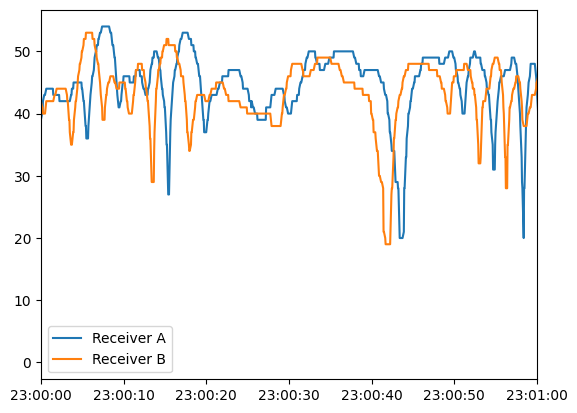

ZeroDivisionError: division by zero

In [ ]:
plt.plot(sat15["datetime"], sat15["snr1_A"], label="Receiver A")
plt.plot(sat15["datetime"], sat15["snr1_B"], label="Receiver B")
plt.xlim(
       pd.Timestamp("2022-10-04 23:00:00"),
      pd.Timestamp("2022-10-04 23:01:00")
    )
plt.legend()
plt.show()



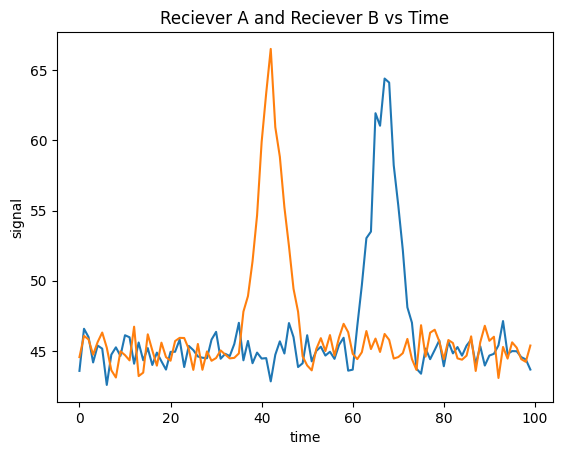

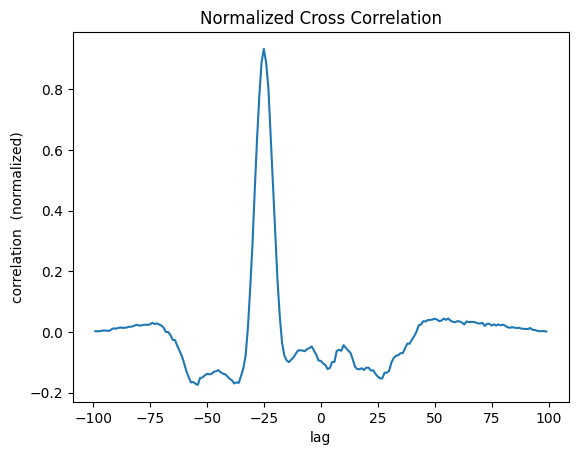

The max correlation is : 0.9324238161759106
The lag is: -25
Error: 13


In [ ]:
from dummycrosscor import cross_correlation

 #need to normalize time here from datetime to just time
 #function in old code

 #datetime to time
def datetime_to_seconds(df, time_column="datetime"):
    df = df.copy()

    # Seconds since first measurement
    df["time_sec"] = (
        df[time_column] - df[time_column].iloc[0] #simply measure change in time
    ).dt.total_seconds()

    return df

sat15 = datetime_to_seconds(sat15)

correlation, lag_b = cross_correlation(sat15["snr1_A"], sat15["snr1_B"])

print(f'The max correlation is : {correlation}')
print(f'The lag is: {lag_b}')
